## Preliminary data analysis

In [92]:
# Packages
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

In [85]:
# Loading the data
metadata = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/metadata.csv")
meth = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/DNAm.csv")
cnv = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/CNV.csv")
rna = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/RNASeq.csv")

In [86]:
# Use sample names as rownames in metadaat
metadata = metadata.set_index("patient_id")

# Reformat sample names
cnv["sample_id"] = cnv["sample_id"].str.replace(".", "-", regex=False)
rna["sample_id"] = rna["sample_id"].str.replace(".", "-", regex=False)
meth["sample_id"] = meth["sample_id"].str.replace(".", "-", regex=False)

def shorten_tcga_id(x):
    
    parts = x.split("-")
    # TCGA barcode structure: sample-level ends at element 4
    # if there are more parts → strip last two
    if len(parts) > 4:
        return "-".join(parts[:4])
    return x

cnv["sample_id"] = cnv["sample_id"].apply(shorten_tcga_id)
rna["sample_id"] = rna["sample_id"].apply(shorten_tcga_id)
meth["sample_id"] = meth["sample_id"].apply(shorten_tcga_id)

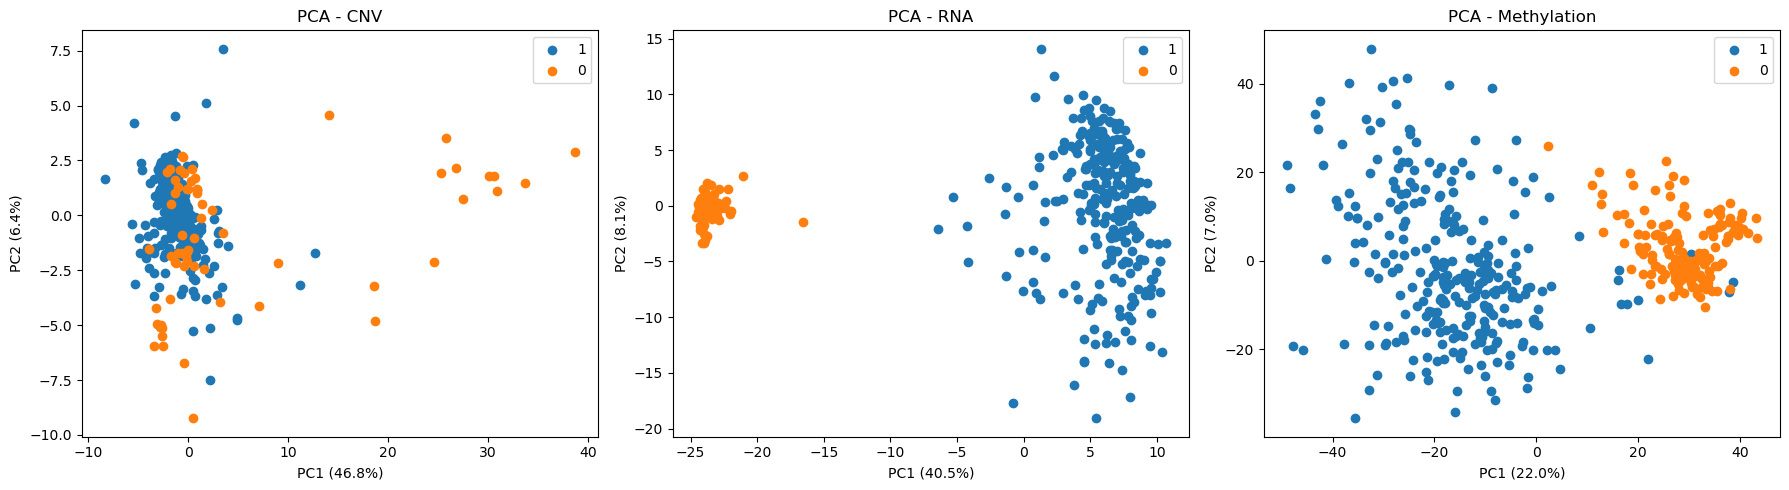

In [ ]:
# CNV
pca_cnv_model = PCA(n_components=2)
pca_cnv = pca_cnv_model.fit_transform(cnv.drop(columns="sample_id"))
var_cnv = pca_cnv_model.explained_variance_ratio_

# RNA
pca_rna_model = PCA(n_components=2)
pca_rna = pca_rna_model.fit_transform(rna.drop(columns="sample_id"))
var_rna = pca_rna_model.explained_variance_ratio_

# Methylation
pca_meth_model = PCA(n_components=2)
pca_meth = pca_meth_model.fit_transform(meth.drop(columns="sample_id"))
var_meth = pca_meth_model.explained_variance_ratio_

plt.figure(figsize=(18,5))

# CNV
plt.subplot(1,3,1)

for s in pca_df_cnv["status"].dropna().unique():
    tmp = pca_df_cnv[pca_df_cnv["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_cnv[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_cnv[1]*100:.1f}%)")
plt.title("PCA - CNV")
plt.legend()

# RNA
plt.subplot(1,3,2)
for s in pca_df_rna["status"].dropna().unique():
    tmp = pca_df_rna[pca_df_rna["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_rna[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_rna[1]*100:.1f}%)")
plt.title("PCA - RNA")
plt.legend()

# Methylation

plt.subplot(1,3,3)
for s in pca_df_meth["status"].dropna().unique():
    tmp = pca_df_meth[pca_df_meth["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_meth[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_meth[1]*100:.1f}%)")
plt.title("PCA - Methylation")
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
# Differential CNV / Expression / Methylation

# Define function
def differential_analysis(labels, matrix, adjustment_method="fdr_bh"):

    results = []

    # ensure numpy/pandas alignment
    labels = np.array(labels)

    for gene in matrix.columns:
        groups = np.unique(labels)
        group1 = matrix.loc[labels == groups[0], gene]
        group2 = matrix.loc[labels != groups[0], gene]
        stat, p = ranksums(group1, group2)
        diff_in_means = np.mean(group1) - np.mean(group2)

        results.append((gene, stat, p, diff_in_means))
    df = pd.DataFrame(results, columns=["gene", "stat", "p_value", "diff_in_means"])

    # multiple testing correction (BH or others)
    reject, p_adj, _, _ = multipletests(df["p_value"], method=adjustment_method)
    df["p_adj"] = p_adj
    df["significant"] = reject
    return df.sort_values("p_adj")

In [113]:
# Differential gene expression

my_labels = metadata.loc[rna["sample_id"],"label"].values
my_genes = rna.drop(columns="sample_id")

differential_analysis(my_labels, my_genes)

,gene,stat,p_value,diff_in_means,p_adj,significant
7610,YTHDF1,13.117850,2.602121e-39,0.589527,5.410933e-38,True
4957,PAICS,13.116576,2.646228e-39,0.568482,5.410933e-38,True
3153,MADD,13.107658,2.976500e-39,0.319214,5.410933e-38,True
11765,ZBTB2,-13.117850,2.602121e-39,-0.387721,5.410933e-38,True
6490,NPFF,-13.117850,2.602121e-39,-0.174349,5.410933e-38,True
...,...,...,...,...,...,...
8178,BACH1,0.008281,9.933924e-01,0.015464,9.936678e-01,False
10343,FRMPD2,-0.003822,9.969503e-01,-0.044408,9.970885e-01,False
12452,POFUT2,-0.003822,9.969503e-01,-0.014274,9.970885e-01,False
13543,FBXO47,-0.003185,9.974586e-01,-0.009724,9.975277e-01,False


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,